In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from varengine.data import load_prices
from varengine.returns import simple_returns, portfolio_losses
from varengine.historical import hs_var, hs_es, rolling_hs, rolling_fhs
from varengine.parametric import (normal_var_es, t_var_es, t_scale_from_sigma,
                                fit_t, rolling_normal, rolling_t,
                                rolling_ewma, risk_contributions)
from varengine.volatility import ewma_variance, ewma_covariance
from varengine.montecarlo import draw_innovations, mc_var_es, rolling_mc

In [2]:
from varengine.config import TICKERS, START, END
from varengine.data import load_prices
prices = load_prices(TICKERS, START, END, refresh=True)

rets = simple_returns(prices)
w = np.full(len(TICKERS), 1 / len(TICKERS))
loss = portfolio_losses(rets, w)

Downloaded prices: 2015-01-02 to 2026-09-18


In [3]:
print(normal_var_es(1.0, 0.99)) # (2.326, 2.665)
s = t_scale_from_sigma(1.0, 4)
print(t_var_es(s, 4, 0.99)) # (2.649, 3.69)
x = stats.t.rvs(4, size=4_000_000, random_state=0) * s
print(hs_var(x, 0.99), hs_es(x, 0.99)) # close to the line above

(np.float64(2.3263478740408408), np.float64(2.665214220345806))
(np.float64(2.6494919067893115), np.float64(3.691510485680755))
2.6515989634819697 3.691189627203212


In [4]:
pc = pd.Series(risk_contributions(rets.cov(), w), index=TICKERS)
print(pc.sort_values(ascending=False).round(3))

SAN.MC     0.230
BBVA.MC    0.221
REP.MC     0.171
TEF.MC     0.149
ITX.MC     0.138
IBE.MC     0.090
dtype: float64


excess kurtosis, raw: 14.964296235167758  standardised: 3.7501703943185216
nu for EWMA-t / MC-t: 5.1971643497830184


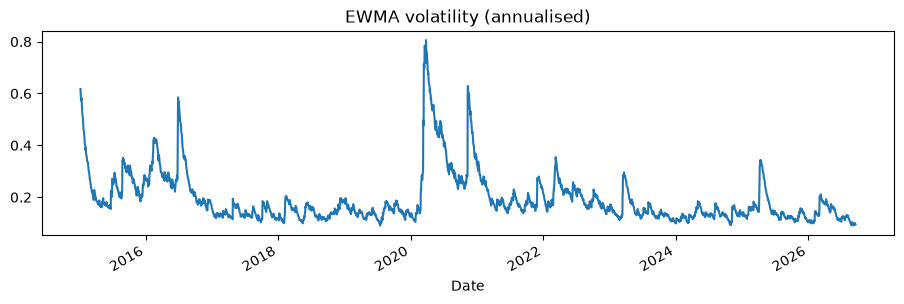

In [5]:
sigma = np.sqrt(ewma_variance(loss))
z = (loss / sigma).dropna()
print("excess kurtosis, raw:", stats.kurtosis(loss), " standardised:", stats.
    kurtosis(z))

nu_z, _ = fit_t(z.iloc[:500]) # first 500 days only
print("nu for EWMA-t / MC-t:", nu_z)

(sigma * np.sqrt(252)).plot(figsize=(11, 3), title="EWMA volatility (annualised)")
plt.show()

In [6]:
models = {
    "HS": rolling_hs(loss),
    "Normal": rolling_normal(loss),
    "t": rolling_t(loss),
    "EWMA-N": rolling_ewma(loss),
    "EWMA-t": rolling_ewma(loss, dist="t", nu=nu_z),
    "FHS": rolling_fhs(loss),
    "MC-N": rolling_mc(rets, w),
    "MC-t": rolling_mc(rets, w, dist="t", nu=nu_z),
}

In [7]:
common = loss.index
for m in models.values():
    common = common.intersection(m.index)

rows = {}
for name, m in models.items():
    m = m.loc[common]
    hits = loss.loc[common] > m["VaR"]
    rows[name] = {"violations": hits.sum(), "rate": hits.mean(),
                "avg VaR": m["VaR"].mean(), "avg ES": m["ES"].mean()}

summary = pd.DataFrame(rows).T
print(f"{len(common)} days, expected violations: {0.01 * len(common):.0f}")
print(summary.round(4))

2494 days, expected violations: 25
        violations    rate  avg VaR  avg ES
HS            28.0  0.0112   0.0315  0.0474
Normal        39.0  0.0156   0.0301  0.0345
t             29.0  0.0116   0.0337  0.0472
EWMA-N        55.0  0.0221   0.0261  0.0299
EWMA-t        33.0  0.0132   0.0291  0.0383
FHS           35.0  0.0140   0.0309  0.0412
MC-N          55.0  0.0221   0.0259  0.0296
MC-t          35.0  0.0140   0.0288  0.0374


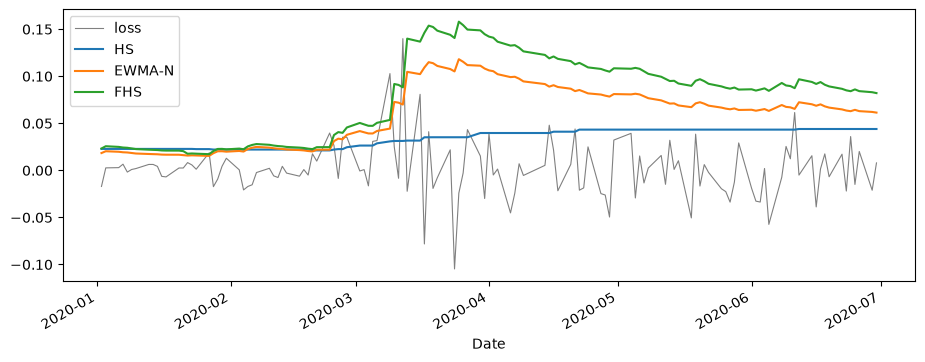

In [8]:
window = slice("2020-01-01", "2020-06-30")
ax = loss.loc[window].plot(figsize=(11, 4), color="grey", lw=0.8, label="loss")
for name in ["HS", "EWMA-N", "FHS"]:
    models[name]["VaR"].loc[window].plot(ax=ax, label=name)
ax.legend()
plt.show()